# Analyse vidéo endoscopique — Détection de polypes avec YOLO

Ce notebook applique le modèle YOLO entraîné (étage 1 de l'architecture hybride) sur des vidéos de coloscopie du dataset HyperKvasir, afin de :

1. Détecter les frames contenant un polype.
2. Générer une **timeline** des détections (timestamps précis).
3. Afficher les **frames clés** avec les boîtes de détection dessinées.
4. Exporter un **rapport CSV** et un **graphique** pour présentation.

Compatible Google Colab (GPU T4 recommandé) ou exécution locale.

**Prérequis :**
- Fichier de poids YOLO : `best.pt` (entraîné dans le notebook YOLO précédent)
- Vidéos HyperKvasir : fichiers `.avi` du dossier `polyps/`

## 1. Installation et imports

In [1]:
!pip install ultralytics opencv-python-headless -q

import os
import cv2
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display
from ultralytics import YOLO

print("Imports OK")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports OK


## 2. Configuration

Adapte les chemins selon ton environnement (Colab ou local).

In [2]:
# Montage Google Drive
from google.colab import drive
drive.mount('/content/drive')

# --- Chemins à adapter ---
YOLO_WEIGHTS = "best.pt"          # chemin vers ton fichier best.pt

# Adapte ce chemin selon où tu as mis le dossier sur ton Drive
VIDEO_FOLDER = "/content/drive/MyDrive/polyps/"  # à adapter si ton dossier est ailleurs

# --- Paramètres de détection ---
CONF_THRESHOLD = 0.25
FRAME_SKIP = 5
MIN_DETECTION_DURATION_S = 0.5

# Vérification
assert os.path.exists(YOLO_WEIGHTS), f"Fichier de poids introuvable : {YOLO_WEIGHTS}"
video_files = [f for f in os.listdir(VIDEO_FOLDER) if f.endswith(".avi")]
assert len(video_files) > 0, f"Aucune vidéo .avi trouvée dans : {VIDEO_FOLDER}"
print(f"Modèle YOLO : {YOLO_WEIGHTS}")
print(f"Vidéos trouvées : {len(video_files)}")
for v in video_files:
    print(f"  - {v}")


Mounted at /content/drive
Modèle YOLO : best.pt
Vidéos trouvées : 72
  - a47dce89-f633-4c51-a4e7-9506ca513839.avi
  - f9a29376-1672-4b6f-97c7-8ed490a58390.avi
  - a6340694-7315-4e1b-b8a5-c048df133d79.avi
  - 76866169-90d1-42fa-ab86-0ee7bb56ea01.avi
  - 89a4fc64-d698-4c09-ad17-f89257182cc2.avi
  - 73bad003-9b4b-43b7-a8bf-04b6a66ecb1e.avi
  - 26c197fc-9b0a-47da-a44c-4cff4ed3b95d.avi
  - 8db217ce-cfd3-4aba-946d-8d2ca9f6d72e.avi
  - 39de6fcf-d914-4c88-87d6-f0d11d865fd2.avi
  - 8a1d3d3c-a05f-4837-9c79-de38ecb4ac2e.avi
  - 7cfdbb45-a132-4a04-8e6e-72270e3c7792.avi
  - 07bf7341-7ddd-44a0-8b31-36842b8761fa.avi
  - f75949a3-bd10-4762-a7d5-1e5e42fae8e4.avi
  - 5c5b3692-51a0-42fc-8836-923448e3b018.avi
  - 4c0cae22-4945-4f17-a60b-23688b485d91.avi
  - 5b2f37fb-8365-4b75-85c1-731e5ce120e6.avi
  - 3e64e5be-1701-4b3c-a0d7-a54c4a57ad7a.avi
  - 3af11f3a-f8f4-4c47-aab1-da489a443d39.avi
  - 2a200509-e1d3-46bd-8ae7-7fb1a8491709.avi
  - 1f7e03fd-06da-4823-94a6-11293897f545.avi
  - ee095f18-817c-4160-88f2-1ea

## 3. Chargement du modèle YOLO

In [3]:
model = YOLO(YOLO_WEIGHTS)
print("Modèle YOLO chargé :", YOLO_WEIGHTS)


Modèle YOLO chargé : best.pt


## 4. Fonction principale d'analyse vidéo

La fonction analyse une vidéo frame par frame, détecte les polypes, et retourne une liste de détections avec leurs timestamps.

In [4]:
def analyze_video(video_path, model, conf=0.25, frame_skip=5):
    """
    Analyse une vidéo frame par frame avec YOLO.

    Retourne un DataFrame avec les colonnes :
    - frame_idx    : index de la frame analysée
    - timestamp_s  : timestamp en secondes
    - timestamp    : timestamp formaté HH:MM:SS
    - detected     : True si au moins un polype détecté
    - n_boxes      : nombre de boîtes détectées
    - max_conf     : confiance maximale parmi les détections
    - boxes        : liste des boîtes (x1,y1,x2,y2,conf)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Impossible d'ouvrir la vidéo : {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_s = total_frames / fps

    print(f"Vidéo : {os.path.basename(video_path)}")
    print(f"  FPS: {fps:.1f} | Frames: {total_frames} | Durée: {duration_s:.1f}s ({duration_s/60:.1f} min)")

    rows = []
    frame_idx = 0
    analyzed = 0
    start_time = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_skip == 0:
            result = model.predict(frame, conf=conf, verbose=False)[0]
            boxes_raw = result.boxes
            detected = len(boxes_raw) > 0
            n_boxes = len(boxes_raw)
            max_conf = float(boxes_raw.conf.max()) if detected else 0.0

            boxes = []
            if detected:
                for box in boxes_raw:
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    c = float(box.conf[0])
                    boxes.append((x1, y1, x2, y2, c))

            ts_s = frame_idx / fps
            h = int(ts_s // 3600)
            m = int((ts_s % 3600) // 60)
            s = int(ts_s % 60)
            ts_str = f"{h:02d}:{m:02d}:{s:02d}"

            rows.append({
                "frame_idx": frame_idx,
                "timestamp_s": round(ts_s, 2),
                "timestamp": ts_str,
                "detected": detected,
                "n_boxes": n_boxes,
                "max_conf": round(max_conf, 4),
                "boxes": boxes,
            })
            analyzed += 1

        frame_idx += 1

    cap.release()
    elapsed = time.time() - start_time
    print(f"  Frames analysées: {analyzed} | Temps: {elapsed:.1f}s")

    return pd.DataFrame(rows), fps, total_frames


## 5. Extraction des segments de détection (timeline)

Cette fonction regroupe les frames consécutives avec détection pour former des **segments temporels** (début → fin de chaque polype visible), plus lisibles qu'une liste de frames individuelles.

In [5]:
def extract_segments(df, fps, frame_skip, min_duration_s=0.5):
    """
    Regroupe les frames détectées consécutives en segments temporels.

    Retourne une liste de dicts :
    - start_s, start_ts  : début du segment
    - end_s, end_ts      : fin du segment
    - duration_s         : durée
    - max_conf           : confiance maximale dans le segment
    - n_frames           : nombre de frames avec détection
    """
    detected_rows = df[df["detected"]].copy()
    if detected_rows.empty:
        return []

    segments = []
    gap_threshold = (frame_skip / fps) * 3  # tolérance de 3 frames analysées consécutives

    seg_start = None
    seg_end = None
    seg_max_conf = 0
    seg_n_frames = 0

    for _, row in detected_rows.iterrows():
        ts = row["timestamp_s"]

        if seg_start is None:
            seg_start = ts
            seg_end = ts
            seg_max_conf = row["max_conf"]
            seg_n_frames = 1
        elif ts - seg_end <= gap_threshold:
            seg_end = ts
            seg_max_conf = max(seg_max_conf, row["max_conf"])
            seg_n_frames += 1
        else:
            # Fermer le segment courant
            dur = seg_end - seg_start
            if dur >= min_duration_s:
                def fmt(s):
                    h=int(s//3600); m=int((s%3600)//60); sec=int(s%60)
                    return f"{h:02d}:{m:02d}:{sec:02d}"
                segments.append({
                    "start_s": seg_start, "start_ts": fmt(seg_start),
                    "end_s": seg_end, "end_ts": fmt(seg_end),
                    "duration_s": round(seg_end - seg_start, 2),
                    "max_conf": round(seg_max_conf, 4),
                    "n_frames": seg_n_frames,
                })
            seg_start = ts
            seg_end = ts
            seg_max_conf = row["max_conf"]
            seg_n_frames = 1

    if seg_start is not None:
        dur = seg_end - seg_start
        if dur >= min_duration_s:
            def fmt(s):
                h=int(s//3600); m=int((s%3600)//60); sec=int(s%60)
                return f"{h:02d}:{m:02d}:{sec:02d}"
            segments.append({
                "start_s": seg_start, "start_ts": fmt(seg_start),
                "end_s": seg_end, "end_ts": fmt(seg_end),
                "duration_s": round(seg_end - seg_start, 2),
                "max_conf": round(seg_max_conf, 4),
                "n_frames": seg_n_frames,
            })

    return segments


## 6. Visualisation des frames clés avec boîtes de détection

Pour chaque segment détecté, on extrait la frame avec la meilleure confiance et on affiche la boîte de détection dessinée dessus.

In [6]:
def show_key_frames(video_path, df, segments, max_frames=6):
    """
    Affiche les frames les plus représentatives de chaque segment détecté,
    avec les boîtes YOLO dessinées, en grille matplotlib.
    """
    if not segments:
        print("Aucun segment détecté à afficher.")
        return

    key_frames = []
    for seg in segments[:max_frames]:
        mask = (
            (df["timestamp_s"] >= seg["start_s"]) &
            (df["timestamp_s"] <= seg["end_s"]) &
            (df["detected"])
        )
        best_row = df[mask].nlargest(1, "max_conf").iloc[0]
        key_frames.append((seg, best_row))

    cap = cv2.VideoCapture(video_path)
    n = len(key_frames)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    if n == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]

    for idx, (seg, row) in enumerate(key_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(row["frame_idx"]))
        ret, frame = cap.read()
        ax = axes[idx // cols][idx % cols]

        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            ax.imshow(frame_rgb)
            for (x1, y1, x2, y2, conf) in row["boxes"]:
                rect = patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1,
                    linewidth=2, edgecolor="red", facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x1, max(y1 - 6, 0),
                        "polype " + f"{conf:.0%}",
                        color="red", fontsize=9, fontweight="bold")

        start_ts = seg["start_ts"]
        end_ts = seg["end_ts"]
        dur = seg["duration_s"]
        conf_max = seg["max_conf"]
        ax.set_title(
            f"Segment {idx+1} | {start_ts} -> {end_ts}\n"
            f"Duree: {dur:.1f}s | Conf: {conf_max:.0%}",
            fontsize=10
        )
        ax.axis("off")

    for idx in range(n, rows * cols):
        axes[idx // cols][idx % cols].axis("off")

    cap.release()
    video_name = os.path.basename(video_path)
    plt.suptitle(
        f"Frames cles — {video_name} ({n} segment(s) detecte(s))",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("key_frames.png", dpi=150, bbox_inches="tight")
    plt.show()


## 7. Graphique timeline — présence du polype dans le temps

Visualisation de la **présence/absence** du polype tout au long de la vidéo, et du **score de confiance** au fil du temps.

In [7]:
def plot_timeline(df, segments, video_name, duration_s):
    """
    Affiche deux graphiques superposés :
    1. Score de confiance par frame (courbe)
    2. Segments de détection (barres horizontales colorées)
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6),
                                    gridspec_kw={"height_ratios": [3, 1]})

    # Courbe de confiance
    ax1.plot(df["timestamp_s"], df["max_conf"], color="#4C72B0",
              linewidth=0.8, alpha=0.7, label="Confiance YOLO")
    ax1.axhline(CONF_THRESHOLD, color="orange", linestyle="--",
                linewidth=1, label=f"Seuil ({CONF_THRESHOLD})")
    ax1.fill_between(df["timestamp_s"], df["max_conf"],
                      where=df["detected"], alpha=0.3, color="red",
                      label="Détection active")
    ax1.set_ylabel("Confiance")
    ax1.set_ylim(0, 1.05)
    ax1.legend(fontsize=9)
    ax1.set_title(f"Timeline de détection — {video_name}")

    # Barres de segments
    for i, seg in enumerate(segments):
        ax2.barh(0, seg["duration_s"], left=seg["start_s"],
                  height=0.6, color="red", alpha=0.7)
        ax2.text(
            seg["start_s"] + seg["duration_s"] / 2, 0,
            f"{seg['start_ts']}",
            ha="center", va="center", fontsize=8, color="white", fontweight="bold"
        )

    ax2.set_xlim(0, duration_s)
    ax2.set_xlabel("Temps (secondes)")
    ax2.set_yticks([])
    ax2.set_ylabel("Détections")

    # Axe X en MM:SS
    def fmt_axis(x, pos):
        m = int(x // 60); s = int(x % 60)
        return f"{m:02d}:{s:02d}"
    from matplotlib.ticker import FuncFormatter
    ax1.xaxis.set_major_formatter(FuncFormatter(fmt_axis))
    ax2.xaxis.set_major_formatter(FuncFormatter(fmt_axis))

    plt.tight_layout()
    plt.savefig("timeline.png", dpi=150, bbox_inches="tight")
    plt.show()


## 8. Analyse complète d'une vidéo + rapport

Lance l'analyse complète sur une vidéo et affiche tous les résultats.

In [8]:
# Choisir une vidéo — change l'index pour en analyser une autre
video_path = os.path.join(VIDEO_FOLDER, video_files[0])

# --- Analyse frame par frame ---
df_results, fps, total_frames = analyze_video(
    video_path, model, conf=CONF_THRESHOLD, frame_skip=FRAME_SKIP
)

duration_s = total_frames / fps

# --- Extraction des segments ---
segments = extract_segments(df_results, fps, FRAME_SKIP, MIN_DETECTION_DURATION_S)

# --- Résumé texte ---
n_detected = df_results["detected"].sum()
n_analyzed = len(df_results)
detection_rate = n_detected / n_analyzed if n_analyzed > 0 else 0

print(f"\n{"="*60}")
print(f"RÉSUMÉ — {os.path.basename(video_path)}")
print(f"{"="*60}")
print(f"Durée totale         : {duration_s/60:.1f} minutes")
print(f"Frames analysées     : {n_analyzed}")
print(f"Frames avec polype   : {n_detected} ({detection_rate:.1%})")
print(f"Segments détectés    : {len(segments)}")
print(f"{"="*60}")

if segments:
    print(f"\nTimeline des polypes détectés :")
    for i, seg in enumerate(segments, 1):
        print(f"  {i}. {seg['start_ts']} → {seg['end_ts']} "
              f"| durée: {seg['duration_s']:.1f}s "
              f"| confiance max: {seg['max_conf']:.0%}")
else:
    print("\nAucun polype détecté dans cette vidéo.")


Vidéo : a47dce89-f633-4c51-a4e7-9506ca513839.avi
  FPS: 25.0 | Frames: 470 | Durée: 18.8s (0.3 min)
  Frames analysées: 94 | Temps: 14.5s

RÉSUMÉ — a47dce89-f633-4c51-a4e7-9506ca513839.avi
Durée totale         : 0.3 minutes
Frames analysées     : 94
Frames avec polype   : 6 (6.4%)
Segments détectés    : 1

Timeline des polypes détectés :
  1. 00:00:02 → 00:00:03 | durée: 0.8s | confiance max: 84%


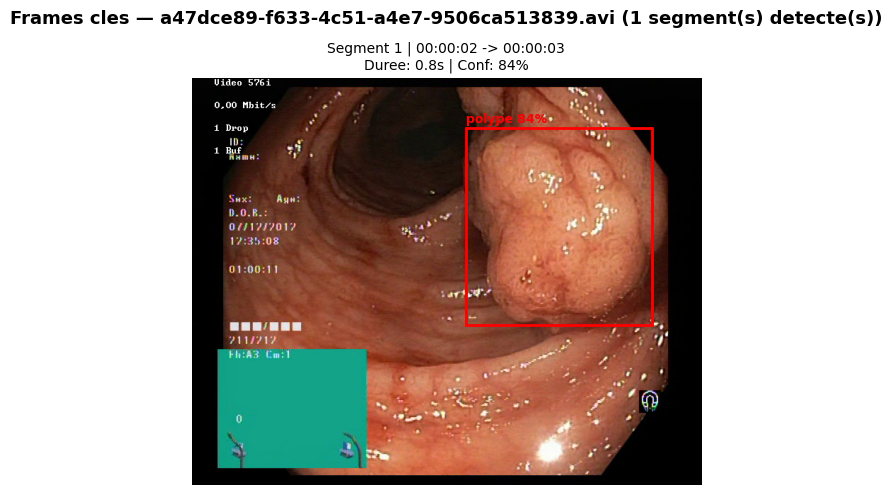

In [9]:
# --- Frames clés avec boîtes ---
show_key_frames(video_path, df_results, segments, max_frames=6)


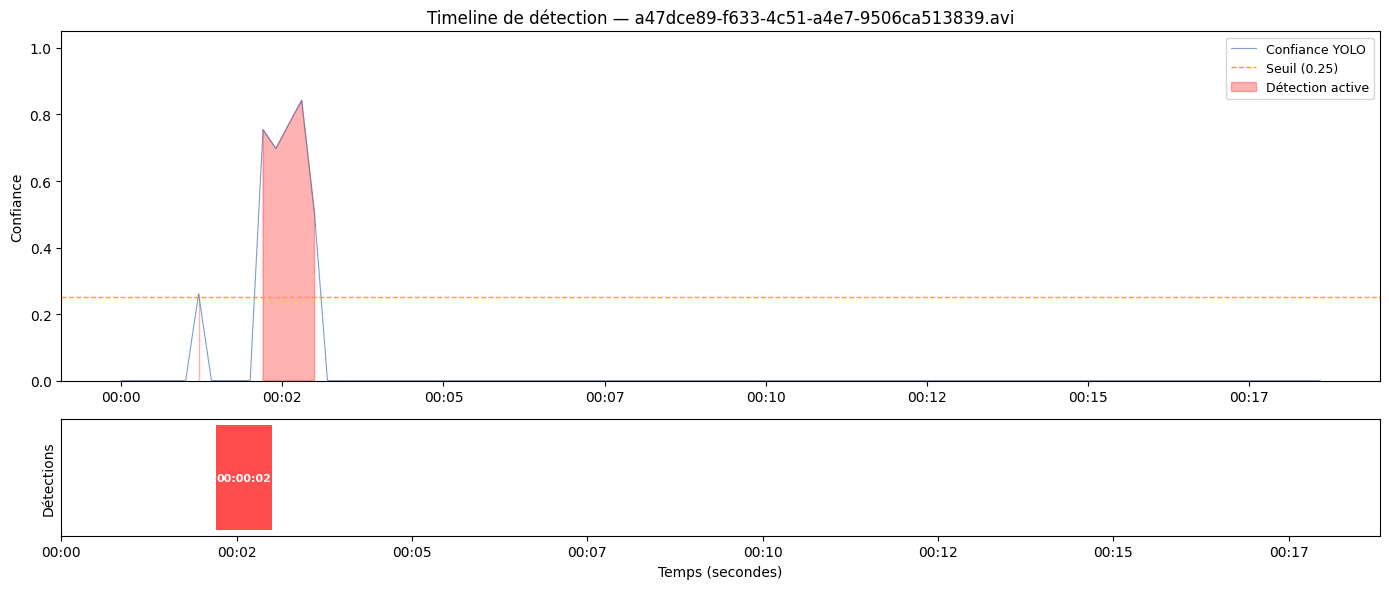

In [10]:
# --- Graphique timeline ---
plot_timeline(df_results, segments, os.path.basename(video_path), duration_s)


In [11]:
# --- Export CSV du rapport ---
report_path = "rapport_detection.csv"
df_export = df_results.drop(columns=["boxes"])  # exclure les boîtes brutes pour la lisibilité
df_export.to_csv(report_path, index=False)
print(f"Rapport sauvegardé : {report_path}")

if segments:
    seg_df = pd.DataFrame(segments)
    seg_df.to_csv("segments_detection.csv", index=False)
    print("Segments sauvegardés : segments_detection.csv")


Rapport sauvegardé : rapport_detection.csv
Segments sauvegardés : segments_detection.csv


## 9. Analyse de toutes les vidéos du dossier

Cette section analyse toutes les vidéos disponibles et produit un tableau comparatif — utile pour présenter les résultats sur l'ensemble du dataset à l'équipe médicale.

In [12]:
all_results = []

for video_file in video_files:
    vpath = os.path.join(VIDEO_FOLDER, video_file)

    try:
        # Vérifier la durée avant d'analyser
        cap = cv2.VideoCapture(vpath)
        fps_check = cap.get(cv2.CAP_PROP_FPS) or 25
        total_check = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration_check = total_check / fps_check
        cap.release()

        # Filtrer : ignorer les vidéos de moins de 5 minutes
        if duration_check < 5 * 60:
            print(f"Ignorée (< 5 min) : {video_file} ({duration_check/60:.1f} min)")
            continue

        print(f"Analyse : {video_file} ({duration_check/60:.1f} min)")

        df_v, fps_v, total_v = analyze_video(
            vpath, model, conf=CONF_THRESHOLD, frame_skip=FRAME_SKIP
        )
        duration_v = total_v / fps_v
        segs_v = extract_segments(df_v, fps_v, FRAME_SKIP, MIN_DETECTION_DURATION_S)

        all_results.append({
            "video": video_file,
            "duree_min": round(duration_v / 60, 2),
            "frames_analysees": len(df_v),
            "frames_avec_detection": int(df_v["detected"].sum()),
            "taux_detection_pct": round(df_v["detected"].mean() * 100, 1),
            "nb_segments": len(segs_v),
            "conf_moyenne": round(df_v[df_v["detected"]]["max_conf"].mean(), 4)
                            if df_v["detected"].any() else 0,
        })

    except Exception as e:
        print(f"Erreur sur {video_file}: {e}")
        all_results.append({"video": video_file, "erreur": str(e)})

print(f"\nVidéos analysées (>= 5 min) : {len(all_results)}")
summary_df = pd.DataFrame(all_results)
display(summary_df)
summary_df.to_csv("rapport_toutes_videos.csv", index=False)
print("Rapport complet sauvegardé : rapport_toutes_videos.csv")


Ignorée (< 5 min) : a47dce89-f633-4c51-a4e7-9506ca513839.avi (0.3 min)
Ignorée (< 5 min) : f9a29376-1672-4b6f-97c7-8ed490a58390.avi (0.7 min)
Ignorée (< 5 min) : a6340694-7315-4e1b-b8a5-c048df133d79.avi (0.5 min)
Ignorée (< 5 min) : 76866169-90d1-42fa-ab86-0ee7bb56ea01.avi (2.2 min)
Ignorée (< 5 min) : 89a4fc64-d698-4c09-ad17-f89257182cc2.avi (3.7 min)
Ignorée (< 5 min) : 73bad003-9b4b-43b7-a8bf-04b6a66ecb1e.avi (0.3 min)
Analyse : 26c197fc-9b0a-47da-a44c-4cff4ed3b95d.avi (8.0 min)
Vidéo : 26c197fc-9b0a-47da-a44c-4cff4ed3b95d.avi
  FPS: 25.0 | Frames: 11951 | Durée: 478.0s (8.0 min)
  Frames analysées: 2391 | Temps: 58.1s
Ignorée (< 5 min) : 8db217ce-cfd3-4aba-946d-8d2ca9f6d72e.avi (0.9 min)
Ignorée (< 5 min) : 39de6fcf-d914-4c88-87d6-f0d11d865fd2.avi (2.0 min)
Ignorée (< 5 min) : 8a1d3d3c-a05f-4837-9c79-de38ecb4ac2e.avi (0.9 min)
Analyse : 7cfdbb45-a132-4a04-8e6e-72270e3c7792.avi (5.2 min)
Vidéo : 7cfdbb45-a132-4a04-8e6e-72270e3c7792.avi
  FPS: 25.0 | Frames: 7784 | Durée: 311.4s (5.2

,video,duree_min,frames_analysees,frames_avec_detection,taux_detection_pct,nb_segments,conf_moyenne
0,26c197fc-9b0a-47da-a44c-4cff4ed3b95d.avi,7.97,2391,277,11.6,30,0.5429
1,7cfdbb45-a132-4a04-8e6e-72270e3c7792.avi,5.19,1557,753,48.4,33,0.7104
2,2330e8a9-3238-4e3f-8d77-0d6ff5dbc0f1.avi,5.92,1776,733,41.3,23,0.7630


Rapport complet sauvegardé : rapport_toutes_videos.csv


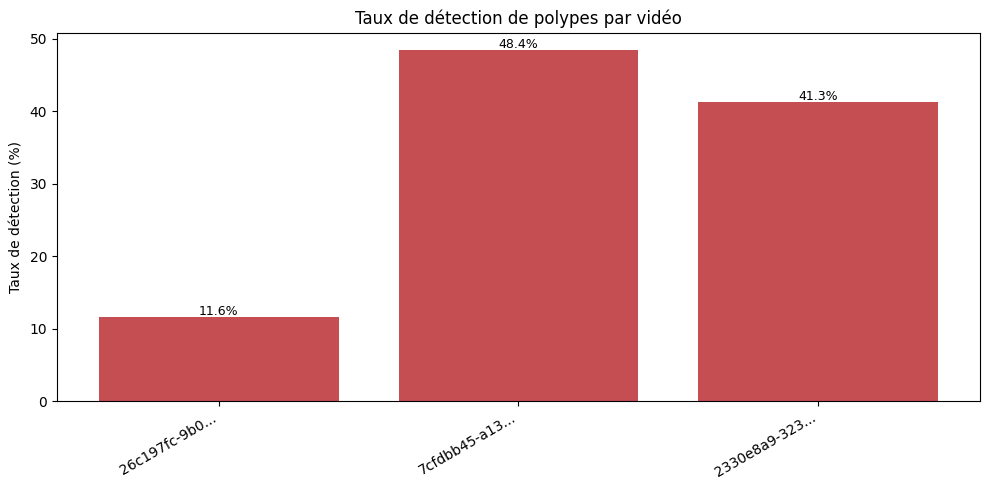

In [13]:
# Graphique comparatif : taux de détection par vidéo
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(summary_df)), summary_df["taux_detection_pct"], color="#C44E52")
ax.set_xticks(range(len(summary_df)))
ax.set_xticklabels([v[:12] + "..." for v in summary_df["video"]], rotation=30, ha="right")
ax.set_ylabel("Taux de détection (%)")
ax.set_title("Taux de détection de polypes par vidéo")
for bar, val in zip(bars, summary_df["taux_detection_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f"{val:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("comparaison_videos.png", dpi=150, bbox_inches="tight")
plt.show()


## Résumé pour l'équipe médicale

Ce notebook produit les livrables suivants :

- `rapport_detection.csv` — résultats frame par frame pour la première vidéo analysée.
- `segments_detection.csv` — timeline des segments détectés (timestamp début/fin, durée, confiance).
- `rapport_toutes_videos.csv` — tableau comparatif sur l'ensemble du dataset.
- `key_frames.png` — frames clés avec les boîtes de détection.
- `timeline.png` — graphique de présence du polype dans le temps.
- `comparaison_videos.png` — taux de détection par vidéo.

**Prochaine étape proposée :** si les résultats sont jugés insuffisants (rappel trop bas), il sera possible de ré-entraîner YOLO directement sur des frames extraites de ces vidéos HyperKvasir (avec leurs annotations), pour améliorer la robustesse sur ce type d'images en mouvement.